In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('../dataset/wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [7]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [9]:
df.shape

(178, 3)

In [10]:
df.isnull().sum()

Class label    0
Alcohol        0
Malic acid     0
dtype: int64

<Axes: xlabel='Alcohol', ylabel='Density'>

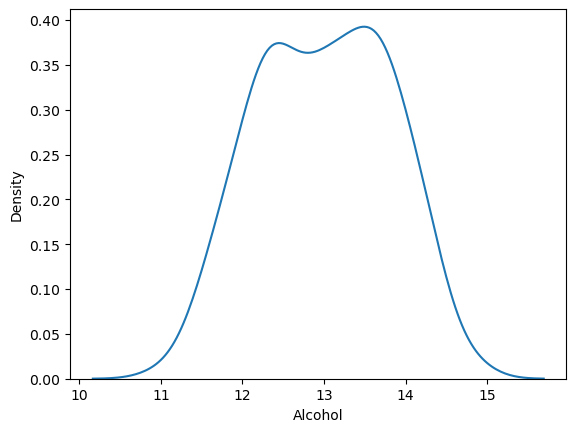

In [12]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Class label', ylabel='Density'>

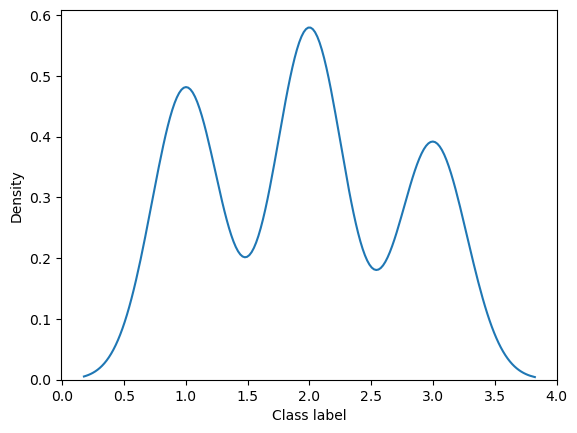

In [13]:
sns.kdeplot(df['Class label'])

<Axes: xlabel='Malic acid', ylabel='Density'>

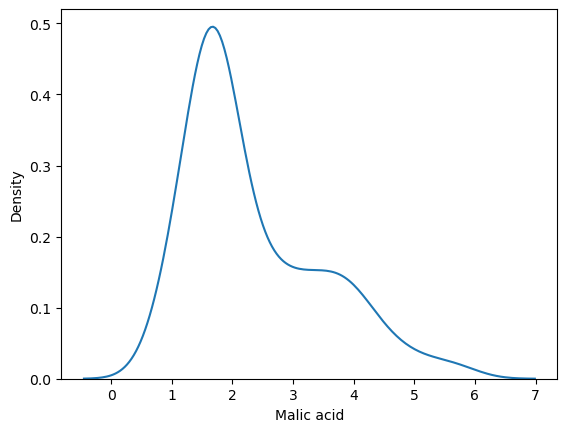

In [14]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

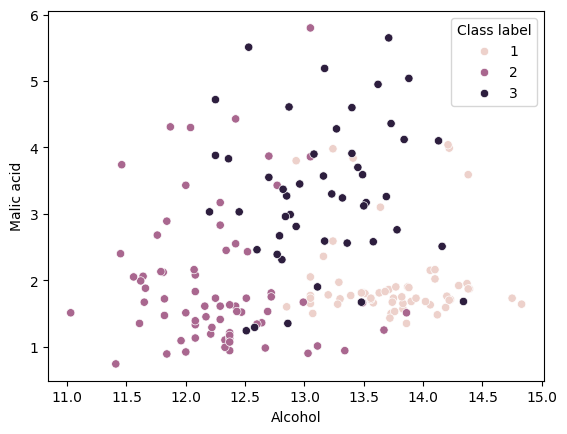

In [20]:
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['Class label'])

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Class label',axis=1),
                                                      df['Class label'],
                                                       test_size=0.2,
                                                      random_state=0)

In [28]:
X_train.shape

(142, 2)

In [29]:
X_test.shape

(36, 2)

In [32]:
X_train

,Alcohol,Malic acid
161,13.69,3.26
92,12.69,1.53
94,11.62,1.99
174,13.40,3.91
24,13.50,1.81
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [31]:
X_test

,Alcohol,Malic acid
54,13.74,1.67
151,12.79,2.67
63,12.37,1.13
55,13.56,1.73
123,13.05,5.80
121,11.56,2.05
7,14.06,2.15
160,12.36,3.83
106,12.25,1.73
90,12.08,1.83


In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [35]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [37]:
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [39]:
X_train_scaled

,Alcohol,Malic acid
0,0.715054,0.513238
1,0.446237,0.160896
2,0.158602,0.254582
3,0.637097,0.645621
4,0.663978,0.217923
...,...,...
137,0.212366,0.199593
138,0.360215,0.087576
139,0.373656,0.177189
140,0.771505,0.191446


Text(0, 0.5, 'malic acid')

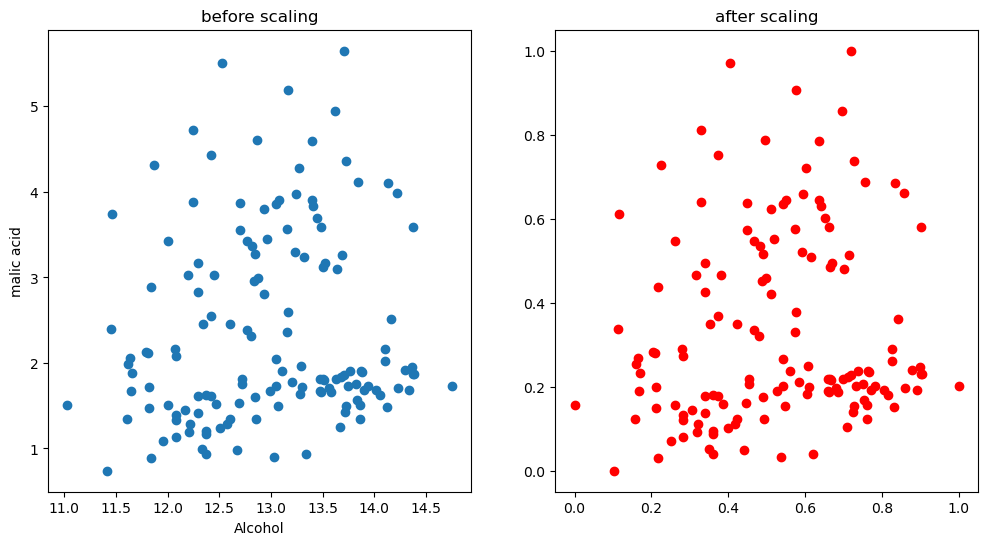

In [49]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,6))

ax1.set_title('before scaling')
ax1.scatter(X_train['Alcohol'],X_train['Malic acid'])  
ax1.set_xlabel('Alcohol')
ax1.set_ylabel('malic acid')

ax2.set_title('after scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'],color='red')
ax1.set_xlabel('Alcohol')
ax1.set_ylabel('malic acid')


<Axes: xlabel='Alcohol', ylabel='Density'>

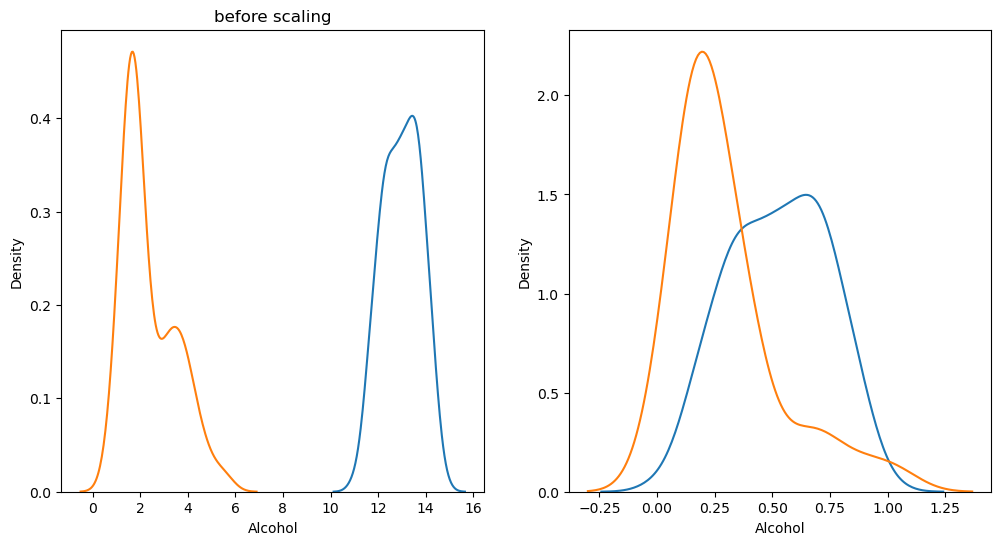

In [58]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,6))
sns.kdeplot(X_train['Alcohol'],ax=ax1)
sns.kdeplot(X_train['Malic acid'],ax=ax1)
ax1.set_title('before scaling')

sns.kdeplot(X_train_scaled['Alcohol'])
sns.kdeplot(X_test_scaled['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Density'>

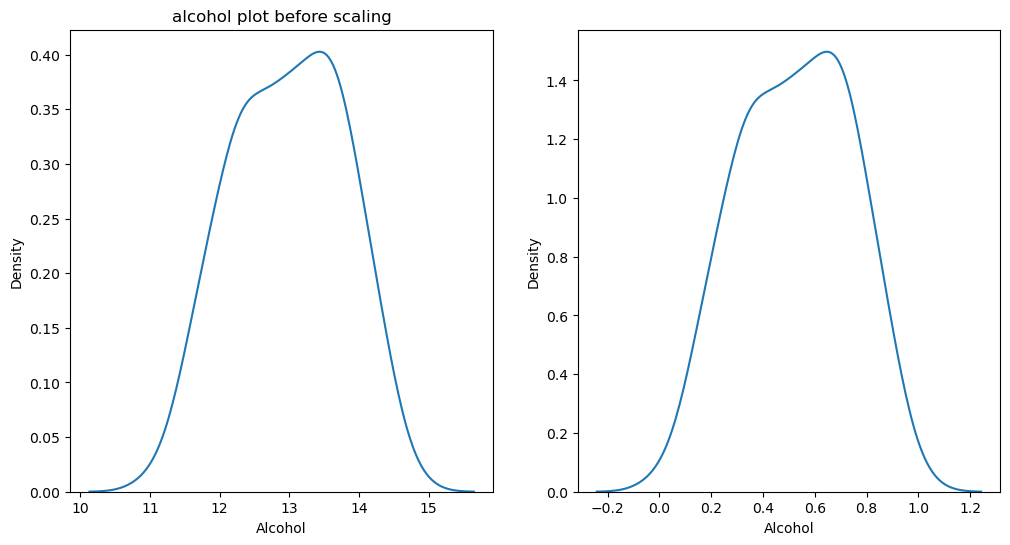

In [62]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,6))
sns.kdeplot(X_train['Alcohol'],ax=ax1)
ax1.set_title('alcohol plot before scaling')

sns.kdeplot(X_train_scaled['Alcohol'],ax=ax2)

<Axes: title={'center': 'malic acid plot after scaling'}, xlabel='Malic acid', ylabel='Density'>

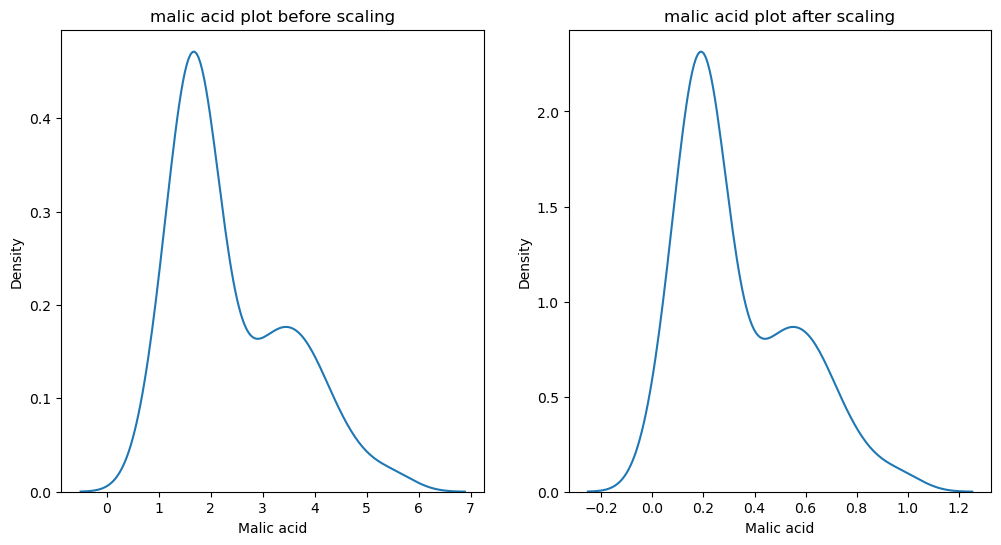

In [66]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,6))
ax1.set_title('malic acid plot before scaling')
sns.kdeplot(X_train['Malic acid'],ax=ax1)

ax2.set_title('malic acid plot after scaling')
sns.kdeplot(X_train_scaled['Malic acid'],ax=ax2)


In [68]:
from sklearn.linear_model import LogisticRegression

In [70]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [71]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [72]:
lr.score(X_train,y_train)

0.7887323943661971

In [73]:
lr_scaled.score(X_train_scaled,y_train)

0.7887323943661971

In [75]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [82]:
from sklearn.metrics import accuracy_score
actual=accuracy_score(y_test,y_pred)
scaled=accuracy_score(y_test,y_pred_scaled)

In [83]:
print('actual',actual)
print('scaled',scaled)

actual 0.7222222222222222
scaled 0.75


In [84]:
from sklearn.metrics import confusion_matrix

In [85]:
actual=confusion_matrix(y_test,y_pred)

In [86]:
print(actual)

[[10  2  2]
 [ 1 13  2]
 [ 3  0  3]]


<Axes: >

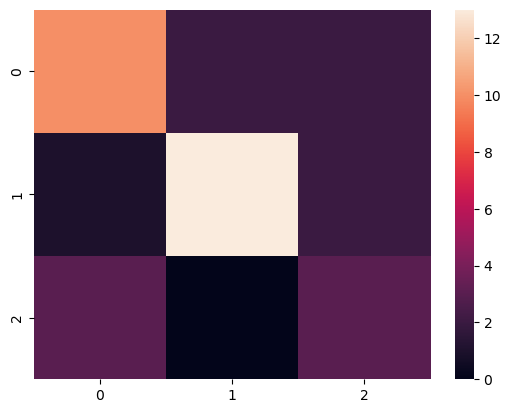

In [87]:
sns.heatmap(actual)

In [89]:
scaled=confusion_matrix(y_test,y_pred_scaled)
